## Changing resolution - MCGS2D

In [1]:
from upxo.ggrowth.mcgs import mcgs
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
total_simulate_time = 0
nruns = 1
for n in range(nruns):
    pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
    start = time.perf_counter()
    pxt.simulate()
    total_simulate_time += time.perf_counter() - start
print(f"Total simulation time: {total_simulate_time:.4f} seconds")
print(f"Average per run: {total_simulate_time/nruns:.4f} seconds")

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 4
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Total simulation time: 6.3344 seconds
Average per run: 6.3344 seconds


In [3]:
start = time.perf_counter()
for n in range(nruns):
    pxt.detect_grains()
wall_time_detect = time.perf_counter() - start
print(f"Wall time: {wall_time_detect:.4f} seconds")
print(f"Average per run: {wall_time_detect/nruns:.4f} seconds")

Using scikit-image for grain identification
Wall time: 0.1116 seconds
Average per run: 0.1116 seconds


(101, 101)
(202, 202)


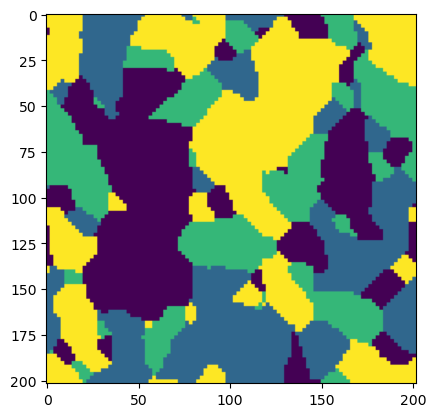

In [4]:
from upxo.gsdataops.grid_ops import rescale_grid_2d
print(pxt.S.shape)
print(rescale_grid_2d(pxt.S, 2, method='nearest').shape)
plt.imshow(rescale_grid_2d(pxt.S, 2, method='nearest'))

In [5]:
from upxo.gsdataops.grid_ops import stretch_grid_2d
stretched_data, _, _, _ = stretch_grid_2d(pxt.S, stretch_x=0.5, stretch_y=0.5, px_size_x=1.0, px_size_y=1.0, method='nearest')
'''plt.imshow(stretched_data)'''

'plt.imshow(stretched_data)'

In [6]:
from upxo.gsdataops.grid_ops import resample_grid_2d
resampled_data, x_new, y_new, xinc_new, yinc_new = resample_grid_2d(pxt.S, pxt.uigrid, sf=0.25, method='nearest')
'''plt.imshow(resampled_data)'''

'plt.imshow(resampled_data)'

In [7]:
tslice = 6

In [8]:
print(f"Total number of grains: {np.unique(pxt.gs[6].lgi).max()}")

Total number of grains: 78


In [9]:
start = time.perf_counter()
nruns = 10
for n in range(nruns):
    pxt.gs[6].char_morph_2d(bbox=False, bbox_ex=False, npixels=False, use_version=2,
                    area=False, aspect_ratio=False, solidity=False, 
                    circularity=False, eccentricity=False, euler_number=False,
                    append=False, saa=True, throw=False, 
                    char_grain_positions=False, find_neigh=False, 
                    char_gb=False, make_skim_prop=False, 
                    get_grain_coords=False)
wall_time_detect = time.perf_counter() - start
print(f"Wall time: {wall_time_detect:.4f} seconds")
print(f"Average per run: {wall_time_detect/nruns:.4f} seconds")

Characterising MC simulation time-slice 6
10.3%, 20.5%, 30.8%, 41.0%, 51.3%, 61.5%, 71.8%, 82.1%, 92.3%, 100.0%Need area, aspect_ratio, major_axis_length, minor_axis_length to correct aspect ratio. Skipping aspect ratio correction.
Characterising MC simulation time-slice 6
10.3%, 20.5%, 30.8%, 41.0%, 51.3%, 61.5%, 71.8%, 82.1%, 92.3%, 100.0%Need area, aspect_ratio, major_axis_length, minor_axis_length to correct aspect ratio. Skipping aspect ratio correction.
Characterising MC simulation time-slice 6
10.3%, 20.5%, 30.8%, 41.0%, 51.3%, 61.5%, 71.8%, 82.1%, 92.3%, 100.0%Need area, aspect_ratio, major_axis_length, minor_axis_length to correct aspect ratio. Skipping aspect ratio correction.
Characterising MC simulation time-slice 6
10.3%, 20.5%, 30.8%, 41.0%, 51.3%, 61.5%, 71.8%, 82.1%, 92.3%, 100.0%Need area, aspect_ratio, major_axis_length, minor_axis_length to correct aspect ratio. Skipping aspect ratio correction.
Characterising MC simulation time-slice 6
10.3%, 20.5%, 30.8%, 41.0%, 51

In [10]:
pxt.gs[4].char_morph_2d(bbox=True, bbox_ex=True, npixels=True, use_version=2,
                area=False, aspect_ratio=True, solidity=False, 
                circularity=True, eccentricity=False, euler_number=False,
                append=False, saa=True, throw=False, 
                char_grain_positions=False, find_neigh=False,
                char_gb=False, make_skim_prop=True, 
                get_grain_coords=True)

pxt.gs[4].g[1].centroid

Characterising MC simulation time-slice 4
10.8%, 21.6%, 32.4%, 43.2%, 54.1%, 64.9%, 75.7%, 86.5%, 97.3%, 100.0%Need area, aspect_ratio, major_axis_length, minor_axis_length to correct aspect ratio. Skipping aspect ratio correction.


(np.float16(71.44), np.float16(3.5))